In [ ]:
%pip install sentence_transformers seaborn matplotlib

C:\Users\sknis\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4760.27it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


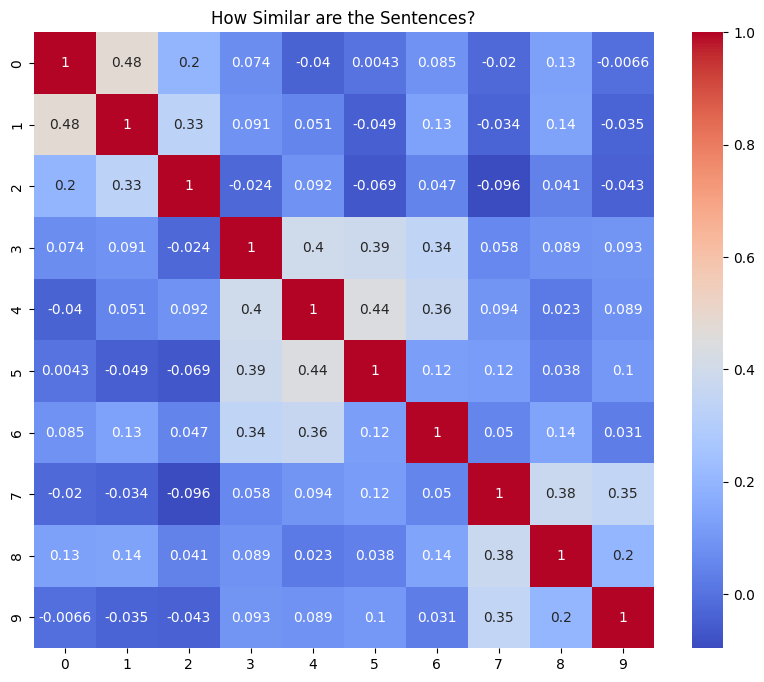

Top 2 matches for: 'The bowler took three wickets in one over'
- The batsman hit a massive six over long-on. (Score: 0.5465)
- The leg-spinner trapped the player leg-before-wicket. (Score: 0.4919)


In [2]:
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Our 10 Sentences
sentences = [
    "The batsman hit a massive six over long-on.", 
    "The leg-spinner trapped the player leg-before-wicket.", 
    "The world cup final went down to the last ball.",
    "Slow-cook the onions until they are golden brown.", 
    "Whisk the eggs and sugar until the mixture is fluffy.", 
    "Add a pinch of salt to enhance the flavor of the soup.", 
    "Bake the cake at 180 degrees for thirty minutes.", 
    "Always use a strong password and two-factor authentication.", 
    "The hacker attempted a phishing attack to steal credentials.", 
    "Keep your software updated to patch security holes."
]

# 2. Load the brain and turn sentences into numbers
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

# 3. Create the Heatmap (The Similarity Matrix)
cosine_sim = util.cos_sim(embeddings, embeddings)
plt.figure(figsize=(10,8))
sns.heatmap(cosine_sim, annot=True, cmap='coolwarm')
plt.title("How Similar are the Sentences?")
plt.show()

# 4. Find the match for the bowler question
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query)
hits = util.semantic_search(query_embedding, embeddings, top_k=2)

print(f"Top 2 matches for: '{query}'")
for hit in hits[0]:
    print(f"- {sentences[hit['corpus_id']]} (Score: {hit['score']:.4f})")